In [ ]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling, simulate_alg_cooling_custom, simulate_alg_cooling_custom2
from sim_library.sequences import RR3_gate, RR3short_gate, exchange10_gate, PulseSequence, DownPulse,  gen_MDFEup_seq, FreeEvolution
from sim_library.sequences2 import RR3short_gate as RR3short_gate2
from sim_library.sequences2 import exchange10_gate as exchange10_gate2
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

: 

In [2]:
path = Path("data/algorithmic cooling/flat/2026-04-13_algcooling_f3_16cycles_1000000atoms_5e+10Hz.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

In [3]:
moms_list[:] = [mom / (hbar * k_eff) for mom in moms_list]

In [4]:
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

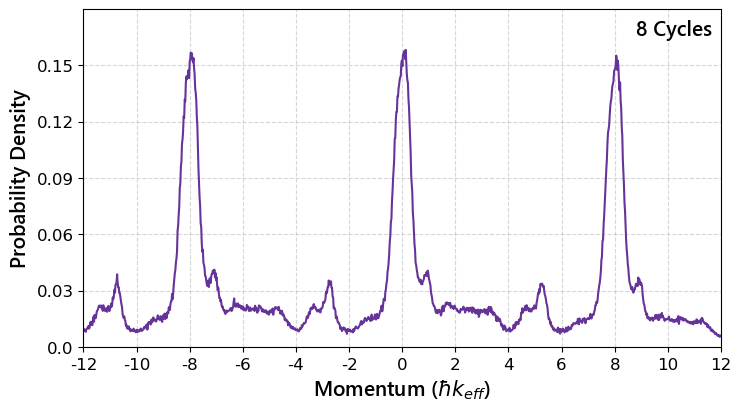

In [108]:
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(1,1, figsize=(7.3, 4), layout= 'constrained')

counts, bin_edges = np.histogram(moms_list[-17], weights=fracs_list[-17], bins = 5000, density=True, range=global_range)
bindiff = bin_edges[1]-bin_edges[0]
binmids = bin_edges[:-1] + (bindiff/2)
ax.plot(binmids, counts, linewidth=1.5, c = 'rebeccapurple')
ax.set_xticks(basis[0::2], basis[0::2], fontsize = 12)
ax.set_xlim(-12,12)

ax.set_ylim(0,0.1799)
ax.set_yticks([0.0, 0.03, 0.06, 0.09, 0.12, 0.15], [0.0, 0.03, 0.06, 0.09, 0.12, 0.15], fontsize = 12)

ax.text(8.8,0.166,rf'{8} Cycles', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax.set_ylabel('Probability Density', fontname = 'Segoe UI', fontsize= 15, fontweight = 'semibold')
ax.set_xlabel(r'Momentum ($\hbar k_{eff}$)', fontname= 'Segoe UI', fontsize= 15, fontweight = 'semibold')

fig.savefig('plots/posters/histograms/flat_1milatoms_500kHz_15muK_16cycles.svg', format='svg', bbox_inches='tight')